# CulRAG: Data Exploration

Explores the Phase 1 sample food dataset (`data/sample_foods.csv`, 50 Indian
foods) and smoke-tests the `VectorRetriever` from `src/retriever.py` on a
handful of representative queries.

This notebook is meant to run without any API keys: retrieval below falls
back to a deterministic local embedding if `OPENAI_API_KEY` is not set, so
Vartan (or anyone else) can run it out of the box before wiring up the full
IFCT dataset.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(project_root / "data" / "sample_foods.csv")
df.head()

,food_name,region,vegetarian,calories,protein_g,carbs_g,fat_g,fiber_g,ayurvedic_type,cooking_method
0,Masoor Dal,North,True,116,9.0,20.1,0.4,7.9,Pitta-pacifying,Pressure-cooked
1,Chana Dal,North,True,164,10.3,27.4,2.6,7.6,Kapha-pacifying,Pressure-cooked
2,Moong Dal,North,True,105,7.5,19.1,0.4,7.6,Tridoshic,Pressure-cooked
3,Toor Dal (Arhar),South,True,121,7.0,22.0,0.4,5.0,Vata-aggravating,Pressure-cooked
4,Urad Dal,South,True,105,7.6,17.9,0.6,4.9,Kapha-aggravating,Pressure-cooked


## 1. Basic stats

In [2]:
print(f"Total foods: {len(df)}")
print(f"Vegetarian: {(df['vegetarian'] == True).sum()} "
      f"({(df['vegetarian'] == True).mean():.0%})")
df[["calories", "protein_g", "carbs_g", "fat_g", "fiber_g"]].describe()

Total foods: 50
Vegetarian: 47 (94%)


,calories,protein_g,carbs_g,fat_g,fiber_g
count,50.000000,50.00000,50.000000,50.000000,50.000000
mean,166.240000,4.97600,17.868000,8.490000,2.568000
std,162.362477,4.30432,14.731785,19.498731,2.119727
min,40.000000,0.00000,0.000000,0.000000,0.000000
25%,105.000000,2.20000,7.250000,0.825000,1.000000
50%,120.500000,3.45000,17.950000,3.400000,2.000000
75%,164.000000,7.00000,22.950000,6.500000,3.575000
max,900.000000,18.00000,98.000000,100.000000,7.900000


In [3]:
df.groupby("region")[["calories", "protein_g", "carbs_g", "fat_g"]].mean().round(1)

,calories,protein_g,carbs_g,fat_g
region,,,,
East,398.0,9.0,3.7,39.3
North,139.8,6.0,16.8,5.6
Pan-India,279.0,2.7,26.4,18.4
South,119.5,4.5,16.7,3.9
West,142.3,3.1,22.9,4.4


## 2. Macro distribution

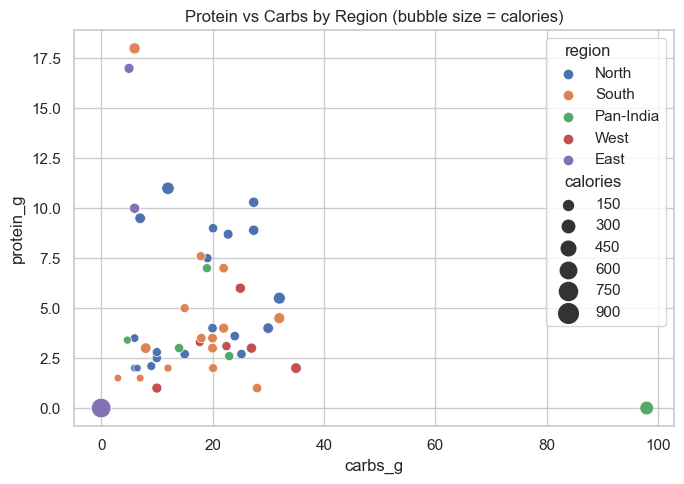

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df, x="carbs_g", y="protein_g", hue="region", size="calories",
    sizes=(30, 200), ax=ax,
)
ax.set_title("Protein vs Carbs by Region (bubble size = calories)")
plt.tight_layout()
plt.show()

## 3. Vegetarian vs non-vegetarian

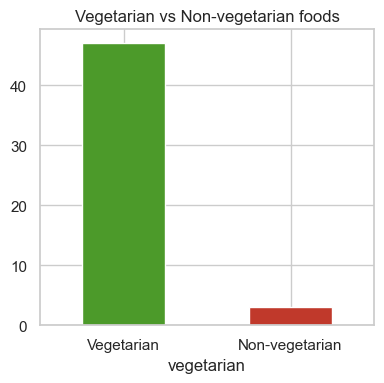

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
df["vegetarian"].value_counts().plot(kind="bar", ax=ax, color=["#4C9A2A", "#C0392B"])
ax.set_xticklabels(["Vegetarian", "Non-vegetarian"], rotation=0)
ax.set_title("Vegetarian vs Non-vegetarian foods")
plt.tight_layout()
plt.show()

## 4. Regional breakdown

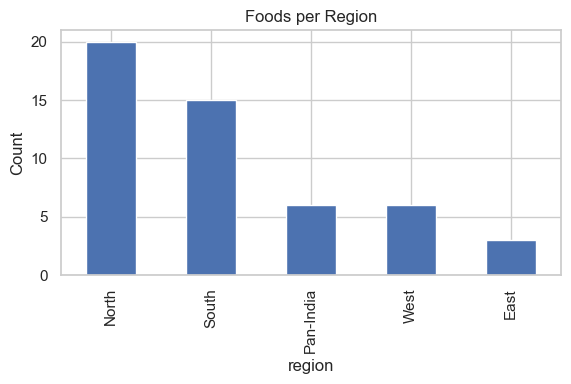

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df["region"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Foods per Region")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Ayurvedic type distribution

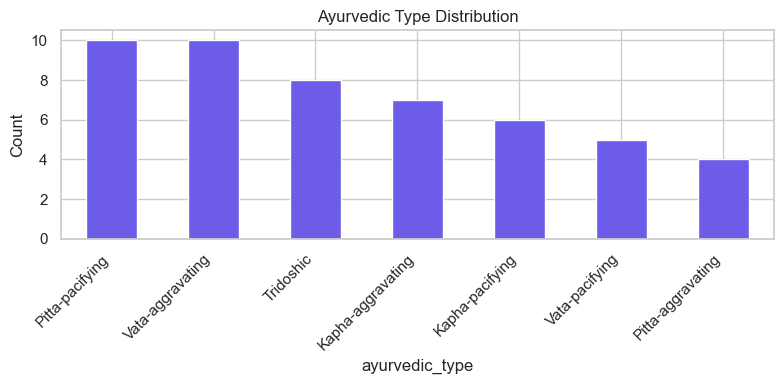

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df["ayurvedic_type"].value_counts().plot(kind="bar", ax=ax, color="#6C5CE7")
ax.set_title("Ayurvedic Type Distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Data quality checks

In [8]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Duplicate food_name entries:", df["food_name"].duplicated().sum())

Missing values per column:
food_name         0
region            0
vegetarian        0
calories          0
protein_g         0
carbs_g           0
fat_g             0
fiber_g           0
ayurvedic_type    0
cooking_method    0
dtype: int64

Dtypes:
food_name          object
region             object
vegetarian           bool
calories            int64
protein_g         float64
carbs_g           float64
fat_g             float64
fiber_g           float64
ayurvedic_type     object
cooking_method     object
dtype: object

Duplicate food_name entries: 0


## 7. Test retrieval

In [9]:
import math
import os
import zlib
from collections import Counter

from src.retriever import VectorRetriever

EMBEDDING_DIM = 64


def local_hash_embed(text: str):
    """Deterministic (cross-process) fallback embedding (no API key required)."""
    vector = [0.0] * EMBEDDING_DIM
    for word, count in Counter(text.lower().split()).items():
        vector[zlib.crc32(word.encode()) % EMBEDDING_DIM] += count
    norm = math.sqrt(sum(v * v for v in vector)) or 1.0
    return [v / norm for v in vector]


use_openai = bool(os.getenv("OPENAI_API_KEY"))
embedding_function = None if use_openai else local_hash_embed
print(f"Using {'OpenAI embeddings' if use_openai else 'local hashing fallback embedding'}")

retriever = VectorRetriever(
    vector_db_type="chroma",
    index_name="culrag_notebook_demo",
    embedding_function=embedding_function,
    persist_directory=None,
)
retriever.initialize_db()

documents = [
    f"{row.food_name}: {row.calories} kcal, protein {row.protein_g}g, "
    f"carbs {row.carbs_g}g, fat {row.fat_g}g, region {row.region}, "
    f"ayurvedic type {row.ayurvedic_type}"
    for row in df.itertuples()
]
metadatas = df.to_dict("records")

retriever.index_documents(documents, metadatas=metadatas)
retriever.get_stats()

Using local hashing fallback embedding


/Users/kavya/culrag/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


{'index_name': 'culrag_notebook_demo',
 'vector_db_type': 'chroma',
 'count': 50,
 'dimension': 1536}

In [10]:
test_queries = [
    "high protein breakfast",
    "low calorie vegetarian dinner",
    "South Indian snack",
    "Pitta-pacifying comfort food",
    "iron rich lentil dish",
]

for query in test_queries:
    print(f"\nQuery: {query!r}")
    results = retriever.search(query, k=5)
    for rank, result in enumerate(results, start=1):
        print(f"  {rank}. {result['metadata']['food_name']:<28} score={result['score']:.3f}")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Query: 'high protein breakfast'
  1. Uttapam                      score=-0.225
  2. Toor Dal (Arhar)             score=-0.261
  3. Poha                         score=-0.383
  4. Coconut Chutney              score=-0.404
  5. Palak Paneer                 score=-0.404

Query: 'low calorie vegetarian dinner'
  1. Urad Dal                     score=-0.515
  2. Payasam (Kheer)              score=-0.515
  3. Curd (Dahi)                  score=-0.515
  4. Sprouted Moong Salad         score=-0.529
  5. Moong Dal                    score=-0.541

Query: 'South Indian snack'
  1. Mustard Oil                  score=-0.440
  2. Masoor Dal                   score=-0.702
  3. Palak Paneer                 score=-0.702
  4. Chana Dal                    score=-0.702
  5. Chana Masala (Chole)         score=-0.728

Query: 'Pitta-pacifying comfort food'
  1. Whole Wheat Roti             score=-0.225
  2. Bajra Roti                   score=-0.440
  3. Baingan Bharta               score=-0.440
  4. Buttermi

In [11]:
retriever.delete_index()

## 8. Findings & recommendations for Phase 2

**Data quality**
- No missing values or duplicate `food_name` entries in the 50-item sample.
- Regional coverage is thin (5 buckets, uneven counts) — expected, since this
  is a hand-picked sample, not the full IFCT 2017 database.

**For Vartan's full IFCT integration**
- Keep the same column schema (`food_name, region, vegetarian, calories,
  protein_g, carbs_g, fat_g, fiber_g, ayurvedic_type, cooking_method`) so
  `CulRAG.load_knowledge_base()` needs no changes.
- With 800+ foods, prefer a persistent Chroma directory (or Pinecone) over
  the in-memory client used here, and switch `embedding_function` to the real
  OpenAI embeddings (this notebook's hashing fallback is a placeholder only,
  useful for offline smoke tests, not semantic quality).
- Retrieval relevance above is a sanity check, not an evaluation — Phase 2's
  `evaluator.py` should measure precision/recall against labeled query-food
  pairs once the larger dataset lands.